In [1]:
%cd ..

/home/fzimin/Projects/depth-poset


In [2]:
import numpy as np
import networkx as nx
import pandas as pd


import matplotlib.pyplot as plt
import seaborn as sns

from src.depth import DepthPoset, ShallowPair
from src.transpositions import Transposition

from IPython.display import display, Markdown

import itertools

from src.equation import Equation
from equations import lemma33


from tqdm.auto import tqdm

import os
import pickle as pkl
from src.hash import hash_boundary_matrix

/home/fzimin/Projects/depth-poset/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Fisualization Tools

## Visualize the Boundary Matrix

In [3]:
def show_boundary_matrix(delta_matrix, ns, ax=None, cmap='Blues', 
                         grid_linewidth=2, grid_alpha=1.0, grid_color='black', set_lim=False):
    if ax is None:
        ax = plt.gca()

    assert len(delta_matrix) == np.sum(ns)

    ax.imshow(delta_matrix, cmap)

    grid_ticks = np.cumsum(np.append(0, ns)) - 0.5
    
    ax.set_xticks(np.arange(len(delta_matrix)))
    ax.set_xticklabels(np.arange(len(delta_matrix)))
    ax.set_xticks(grid_ticks, minor=True)
    ax.set_yticks(np.arange(len(delta_matrix)))
    ax.set_yticklabels(np.arange(len(delta_matrix)))
    ax.set_yticks(grid_ticks, minor=True)

    if set_lim:
        ax.set_xlim(grid_ticks[1], grid_ticks[-1])
        ax.set_ylim(grid_ticks[-2], grid_ticks[0])

    ax.grid(which="minor", linewidth=grid_linewidth, alpha=grid_alpha, color=grid_color)
    

## Markdown Tables

In [4]:
def latex_tuple_sets(s: set):
    if len(s) == 0:
        return r'$\emptyset$'
    else:
        str_s = {(int(a), int(b)) for a, b, in s}
        str_s = f'${str_s}$'
        str_s = str_s.replace('{', r'\{').replace('}', r'\}')
        return str_s

In [5]:
def unite(idx, col, val):
    idx = idx.replace('$', '')
    col = col.replace('$', '')
    val = val.replace('$', '')
    return f"${col.replace(r'\text{Set}', idx)} = {val}$"

In [6]:
def get_succ_pred_table(dp_bt, dp_at, a, b, x, y, transposition_type='birth-birth', **kwargs):
    set_funs = [lemma33.get_pred1, lemma33.get_pred2, lemma33.get_succ1, lemma33.get_succ2]
    
    if transposition_type == 'birth-birth':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, a, y), (dp_at, x, b), ]
    if transposition_type == 'death-death':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, x, b), (dp_at, a, y), ]
    if transposition_type == 'birth-death':
        set_args = [(dp_bt, a, b), (dp_bt, x, y), (dp_at, a, x), (dp_at, b, y), ]
    

    arg_index = np.repeat([r'$\text{{Set}}^\text{{bt}}({a}, {b})$', 
                           r'$\text{{Set}}^\text{{at}}({a}, {b})$'], 2)
    arg_index = [s.format(a=a, b=b) for s, (dp, a, b) in zip(arg_index, set_args)]


    df = pd.DataFrame({f'$\\text{{{f.__name__[4:-1].capitalize()}}}_{f.__name__[-1]}$': [f(*args) for args in set_args] for f in set_funs}, index=arg_index)
    df = df.map(latex_tuple_sets)
    df = df.transpose()

    for idx in df.index:
        for col in df.columns:
            df.loc[idx, col] = unite(idx, col, df.loc[idx, col])

    df = df.iloc[[2, 0, 3, 1]]
    return df

In [7]:
def get_set_funs_table(dp_bt, dp_at, a, b, x, y, transposition_type=None, set_funs=None):
    """
    """
    if set_funs is None:
        if transposition_type == 'birth-birth':
            set_funs = [lemma33.get_l_set, lemma33.get_m_set]
        elif transposition_type == 'death-death':
            set_funs = [lemma33.get_b_set, lemma33.get_n_set]
        else:
            set_funs = []

    dps_dict = {'Before the Transposition': dp_bt, 'After the Transposition': dp_at}
    df = pd.DataFrame({key: [f(item, a, b, x, y) for f in set_funs] for key, item in dps_dict.items()}, 
                      index=[f.__doc__.strip() for f in set_funs])
    df = df.map(latex_tuple_sets)
    return df

In [8]:
def add_params(s, **kwargs):
    """
    """
    res = str(s)
    for key, item in kwargs.items():
        res = res.replace(f'({key}', f'({item}')
        res = res.replace(f'{key})', f'{item})')
    return res


In [9]:
def get_equations_table(equations: list[Equation], **kwargs):
    """
    """
    df = pd.DataFrame([{'eq': eq.__class__.__name__, 
                        'left (formula)': f'${eq.left_str}$', 
                        'left (paramatrized)': f'${add_params(eq.left_str, **kwargs)}$', 
                        'left (value)': eq.left(**kwargs), 
                        'right (formula)': f'${eq.right_str}$', 
                        'right (paramatrized)': f'${add_params(eq.right_str, **kwargs)}$',
                        'right (value)': eq.right(**kwargs), 
                        'correct': eq.is_correct(**kwargs),
                        } for eq in equations])
    df = df.set_index('eq')

    for col in ['left (value)', 'right (value)']:
        df[col] = df[col].apply(latex_tuple_sets)

    return df

In [10]:
def get_transposition_stats():
    pass

# Get Data 

In [11]:
def get_dims(ns):
    return np.concatenate([i*np.ones(n, dtype=int) for i, n in enumerate(ns)])

In [12]:
def get_betti_from_depth_poset(ns: list[int], dp: DepthPoset):
    """
    """
    bs = np.array(ns)
    for node in dp.nodes:
        dim = int(node.dim)
        bs[[dim, dim + 1]] -= 1
    return bs


In [13]:
def get_delta_data(delta, ns, betti=None, path='data/complexes/absract'):
    """
    """
    hash = hash_boundary_matrix(delta)
    filename = os.path.join(path, f'{hash}.pkl')
    try:
        with open(filename, 'rb') as file:
            data = pkl.load(file)
    except FileNotFoundError:
        dims = get_dims(ns)
        dp = DepthPoset.from_border_matrix(delta, dims)
        if betti is None:
            betti = get_betti_from_depth_poset(ns, dp)
        data = {
            'hash': hash, 
            'boundary_matrix': np.array(delta, dtype=bool), 
            'dims': dims, 
            'betti': betti,
            'depth_poset': dp, 
        }

        os.makedirs(path, exist_ok=True)
        with open(filename, 'wb') as file:
            pkl.dump(data, file)
    return data

# Collect Transpositions Data

## Associate Transposition with Equations

In [14]:
@np.vectorize
def get_equation_from_number(i):
    return getattr(lemma33, f'Eq{i:02d}')()

In [15]:
def associate_equations(transposition_type, switch_type, nested):
    """
    """
    if transposition_type == 'birth-birth' and switch_type == 'switch forward':
        return get_equation_from_number(np.arange(8, 16))
    elif transposition_type == 'birth-birth' and switch_type == 'no switch' and nested:
        return get_equation_from_number(np.arange(16, 18))
    elif transposition_type == 'birth-birth' and switch_type == 'switch backward':
        return get_equation_from_number(np.arange(26, 28))
    
    elif transposition_type == 'death-death' and switch_type == 'switch forward':
        return get_equation_from_number(np.arange(28, 36))
    elif transposition_type == 'death-death' and switch_type == 'no switch' and nested:
        return get_equation_from_number(np.arange(36, 38))
    elif transposition_type == 'death-death' and switch_type == 'switch backward':
        return get_equation_from_number(np.arange(46, 48))

    elif transposition_type == 'birth-death' and switch_type == 'switch forward':
        return get_equation_from_number(np.arange(48, 56))
    
    elif switch_type == 'no switch':
        return [lemma33.EqSucc1ab(), lemma33.EqSucc1xy(), lemma33.EqPred1ab(), lemma33.EqPred1xy(), 
                lemma33.EqSucc2ab(), lemma33.EqSucc2xy(), lemma33.EqPred2ab(), lemma33.EqPred2xy()]
    else:
        return []


## Get Transpositions Tables

In [16]:
def check_equations(df_transpositions):
    """
    """
    df_transpositions['eq_objs'] = df_transpositions[['transposition_type', 'switch_type', 'nested']].apply(lambda row: associate_equations(**row), axis=1)
    eqs_objs = np.array(list(set(np.concatenate(df_transpositions['eq_objs']))))
    eqs_names = np.vectorize(lambda x: x.__class__.__name__)(eqs_objs)
    eqs_objs, eqs_names = eqs_objs[np.argsort(eqs_names)], eqs_names[np.argsort(eqs_names)]

    def applyer(eq_obj, row):
        if eq_obj not in row['eq_objs']:
            return None
        try:
            return eq_obj.is_correct(**row)
        except Exception as err:
            return err
    
    for eq_name, eq_obj in zip(eqs_names, eqs_objs):
        df_transpositions[eq_name] = df_transpositions.apply(lambda row: applyer(eq_obj, row), axis=1)

    

    df_transpositions.drop(columns='eq_objs')
    df_transpositions._eq_cols = eqs_names
    return df_transpositions
            

In [17]:
def collect_transpositions(delta, ns, betti=None, path='data/complexes/absract', filter_unpaired: bool=False, do_equation_checks: bool=True):
    """
    """
    df_transpositions = []

    dims = get_dims(ns)

    assert len(delta) == np.sum(ns)
    n = len(delta)

    data_bt = get_delta_data(delta, ns, betti=betti, path=path)
    betti = data_bt['betti']
    
    for cell0, cell1 in itertools.pairwise(range(len(delta))):
        reorder = np.arange(n)
        reorder[[cell0, cell1]] = reorder[[cell1, cell0]]

        data_at = get_delta_data(delta[reorder, :][:, reorder], ns, betti=betti, path=path)
        
        df_transpositions.append(
            {
                'cell0': cell0, 
                'cell1': cell1, 
                'hash_bt': data_bt['hash'], 
                'hash_at': data_at['hash'], 
                'dp_bt': data_bt['depth_poset'], 
                'dp_at': data_at['depth_poset'], 
            }
        )
    df_transpositions = pd.DataFrame(df_transpositions)

    df_transpositions['transposition'] = df_transpositions.apply(lambda row: Transposition(delta, row['cell0'], row['cell1'], dims=dims, order=np.arange(n), dp=row['dp_bt']), axis=1)

    df_transpositions['transposition_type'] = df_transpositions['transposition'].apply(lambda transp: transp.get_transposition_type())
    if filter_unpaired:
        df_transpositions = df_transpositions[df_transpositions['transposition_type'].isin(['birth-birth', 'death-death', 'birth-death'])]
    df_transpositions['switch_type'] = df_transpositions['transposition'].apply(lambda transp: transp.get_switch_type())
    df_transpositions['nested'] = df_transpositions['transposition'].apply(lambda transp: transp.is_nested())

    def get_xyab_from_row(row):
        if row['transposition_type'] not in ['birth-birth', 'death-death', 'birth-death']:
            return None, None, None, None
        return row['transposition'].get_xyab()
    df_transpositions['xyab'] = df_transpositions.apply(get_xyab_from_row, axis=1)
    for i, c in enumerate('xyab'):
        df_transpositions[c] = df_transpositions['xyab'].apply(lambda v: v[i]).astype('Int64')
    df_transpositions = df_transpositions.drop(columns='xyab')

    if do_equation_checks:
        df_transpositions = check_equations(df_transpositions)

    return df_transpositions
    

# Example

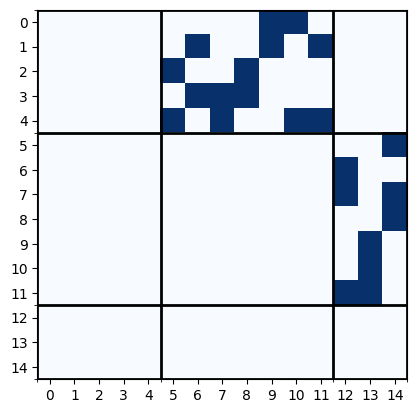

In [18]:
delta_matrix = np.zeros([16, 16], dtype=int)
delta_matrix[0, 1:6] = 1
delta_matrix[1:6, 6:13] = np.array([[1, 1, 0, 0, 0, 0, 0], 
                                    [1, 0, 1, 1, 0, 0, 0], 
                                    [0, 1, 1, 0, 1, 1, 0], 
                                    [0, 0, 0, 1, 1, 0, 1], 
                                    [0, 0, 0, 0, 0, 1, 1]])
delta_matrix[6:13, 13:16] = np.array([[1, 0, 0], 
                                      [1, 0, 0], 
                                      [1, 1, 0], 
                                      [0, 1, 0], 
                                      [0, 1, 1], 
                                      [0, 0, 1], 
                                      [0, 0, 1]])
reorder = np.array([ 0,  1,  2,  5,  4,  3, 11,  9, 10, 12,  6,  7,  8, 14, 13, 15])

ns = [1, 5, 7, 3]
delta_matrix = delta_matrix[reorder, :][:, reorder]

ns = ns[1:]
delta_matrix = delta_matrix[1:, 1:]

show_boundary_matrix(delta_matrix, ns, set_lim=False)

In [19]:
df_transpositions = collect_transpositions(delta_matrix, ns, path='data/complexes/example')


print(f'df_transpositions.shape = {df_transpositions.shape}')
df_transpositions.head()

df_transpositions.shape = (14, 49)


/tmp/ipykernel_257539/3217219537.py:23: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df_transpositions._eq_cols = eqs_names


,cell0,cell1,hash_bt,hash_at,dp_bt,dp_at,transposition,transposition_type,switch_type,nested,...,Eq54,Eq55,EqPred1ab,EqPred1xy,EqPred2ab,EqPred2xy,EqSucc1ab,EqSucc1xy,EqSucc2ab,EqSucc2xy
0,0,1,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,TovqJ-M4DgbWNJ4B4N1SgQXXkCvZMcW4AMP5vrPmzR4,<src.depth.DepthPoset object at 0x7d1dd9e96a80>,<src.depth.DepthPoset object at 0x7d1dd9e95910>,"<0, 1>",birth-unpaired,undefined,False,...,None,None,None,None,None,None,None,None,None,None
1,1,2,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,J2sqbpnQ48LtFe20HsEAUkqy4GGMjhte7HBokhi0RQA,<src.depth.DepthPoset object at 0x7d1dd9e96a80>,<src.depth.DepthPoset object at 0x7d1dd9e97350>,"<1, 2>",birth-birth,switch forward,True,...,None,None,None,None,None,None,None,None,None,None
2,2,3,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,Hch7Jy3ORtkQDDERc_N9PsJoEKcHTDKxRs83iZYppNk,<src.depth.DepthPoset object at 0x7d1dd9e96a80>,<src.depth.DepthPoset object at 0x7d1ddafa7740>,"<2, 3>",birth-birth,no switch,True,...,None,None,None,None,None,None,None,None,None,None
3,3,4,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,vzPUoxuvbCxEsI5SVC188-HNcPhtehVc4RNPBHsZLKg,<src.depth.DepthPoset object at 0x7d1dd9e96a80>,<src.depth.DepthPoset object at 0x7d1dda977920>,"<3, 4>",birth-birth,no switch,False,...,None,None,list index out of range,list index out of range,list index out of range,list index out of range,list index out of range,list index out of range,list index out of range,list index out of range
4,4,5,GD7eloFebJobPBuo8G31RrYtACBtQTjQRT3SOrqPShs,fNCa6cFwHLObhz6fc6vszVaQKaC4NrTlM_gaboU1__U,<src.depth.DepthPoset object at 0x7d1dd9e96a80>,<src.depth.DepthPoset object at 0x7d1dda977dd0>,"<4, 5>",birth-death,no switch,False,...,None,None,list index out of range,list index out of range,list index out of range,list index out of range,list index out of range,list index out of range,list index out of range,list index out of range


In [20]:
index_cols = ['transposition_type', 'switch_type', 'nested']
df_transpositions[np.concatenate([index_cols, df_transpositions._eq_cols])].set_index(index_cols).transpose()

transposition_type birth-unpaired              birth-birth  \
switch_type             undefined           switch forward   
nested                      False                    True    
Eq08                         None  list index out of range   
Eq09                         None  list index out of range   
Eq10                         None  list index out of range   
Eq11                         None  list index out of range   
Eq12                         None  list index out of range   
Eq13                         None  list index out of range   
Eq14                         None  list index out of range   
Eq15                         None  list index out of range   
Eq16                         None                     None   
Eq17                         None                     None   
Eq28                         None                     None   
Eq29                         None                     None   
Eq30                         None                     None   
Eq31                         None                     None   
Eq32                         None                     None   
Eq33                         None                     None   
Eq34                         None                     None   
Eq35                         None                     None   
Eq48                         None                     None   
Eq49                         None                     None   
Eq50                         None                     None   
Eq51                         None                     None   
Eq52                         None                     None   
Eq53                         None                     None   
Eq54                         None                     None   
Eq55                         None                     None   
EqPred1ab                    None                     None   
EqPred1xy                    None                     None   
EqPred2ab                    None                     None   
EqPred2xy                    None                     None   
EqSucc1ab                    None                     None   
EqSucc1xy                    None                     None   
EqSucc2ab                    None                     None   
EqSucc2xy                    None                     None   

transposition_type                                                    \
switch_type                       no switch                            
nested                                True                     False   
Eq08                                   None                     None   
Eq09                                   None                     None   
Eq10                                   None                     None   
Eq11                                   None                     None   
Eq12                                   None                     None   
Eq13                                   None                     None   
Eq14                                   None                     None   
Eq15                                   None                     None   
Eq16                list index out of range                     None   
Eq17                list index out of range                     None   
Eq28                                   None                     None   
Eq29                                   None                     None   
Eq30                                   None                     None   
Eq31                                   None                     None   
Eq32                                   None                     None   
Eq33                                   None                     None   
Eq34                                   None                     None   
Eq35                                   None                     None   
Eq48                                   None                     None   
Eq49                                   None                     None   
Eq50                                   None      

# Generate Complex